In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import json
from tqdm import tqdm

from diffdrr.drr import DRR
from diffdrr.metrics import NormalizedCrossCorrelation2d
from diffdrr.pose import RigidTransform
from diffdrrdata.deepfluoro import DeepFluoroDataset, Transforms

device = torch.device('cpu')
print(f'Device: {device}')

with open('../outputs/dataset_config.json') as f:
    cfg = json.load(f)

SUBJECT_ID = cfg['subject_id']
SUBSAMPLE  = cfg['subsample']

deepfluoro = DeepFluoroDataset(id_number=SUBJECT_ID)
transform  = Transforms(deepfluoro.height // SUBSAMPLE)

drr = DRR(
    deepfluoro.subject,
    sdd=deepfluoro.focal_len,
    height=deepfluoro.height // SUBSAMPLE,
    delx=deepfluoro.delx * SUBSAMPLE,
    x0=deepfluoro.x0,
    y0=deepfluoro.y0,
).to(device)

print(f'✅ DRR renderer ready')

Device: cpu
✅ DRR renderer ready


In [3]:
def perturb_pose(pose, rot_deg=5.0, trans_mm=10.0):
    mat = pose.matrix.clone()
    
    r = torch.deg2rad(torch.FloatTensor(3).uniform_(-rot_deg, rot_deg))
    cx, cy, cz = torch.cos(r)
    sx, sy, sz = torch.sin(r)
    Rx = torch.tensor([[1,0,0],[0,cx,-sx],[0,sx,cx]])
    Ry = torch.tensor([[cy,0,sy],[0,1,0],[-sy,0,cy]])
    Rz = torch.tensor([[cz,-sz,0],[sz,cz,0],[0,0,1]])
    dR = (Rz @ Ry @ Rx).float()
    dt = torch.FloatTensor(3).uniform_(-trans_mm, trans_mm)
    
    mat[0, :3, :3] = dR @ mat[0, :3, :3]
    mat[0, :3,  3] = mat[0, :3, 3] + dt
    
    return RigidTransform(mat)

torch.manual_seed(1)
FRAME_IDX = 20
gt_img, gt_pose = deepfluoro[FRAME_IDX]
gt_pose_dev = gt_pose.to(device)
init_pose   = perturb_pose(gt_pose).to(device)

gt_t   = gt_pose.matrix[0, :3, 3].numpy()
init_t = init_pose.matrix[0, :3, 3].cpu().numpy()
print(f'GT translation:      {gt_t.round(2)} mm')
print(f'Perturbed start:     {init_t.round(2)} mm')
print(f'Initial trans error: {np.linalg.norm(gt_t - init_t):.2f} mm')

GT translation:      [ -12.51 -793.04   -8.53] mm
Perturbed start:     [  -7.81 -802.46   -2.53] mm
Initial trans error: 12.11 mm


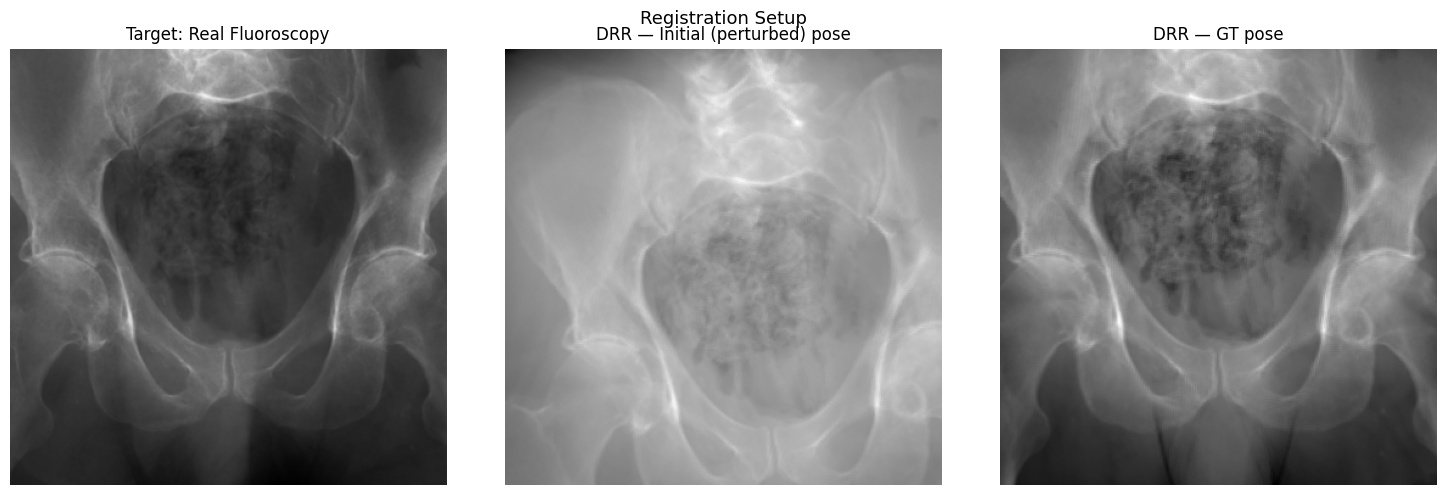

In [25]:
with torch.no_grad():
    drr_gt   = transform(drr(gt_pose_dev).cpu())
    drr_init = transform(drr(init_pose).cpu())
gt_img_t = transform(gt_img)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Registration Setup', fontsize=13)
axes[0].imshow(gt_img_t.squeeze().numpy(),  cmap='gray')
axes[0].set_title('Target: Real Fluoroscopy')
axes[1].imshow(drr_init.squeeze().numpy(), cmap='gray')
axes[1].set_title('DRR — Initial (perturbed) pose')
axes[2].imshow(drr_gt.squeeze().numpy(),   cmap='gray')
axes[2].set_title('DRR — GT pose')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.savefig('../outputs/registration_setup.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
class PoseOptimizer(nn.Module):
    def __init__(self, initial_pose):
        super().__init__()
        mat = initial_pose.matrix[0]
        R   = mat[:3, :3]
        t   = mat[:3,  3]
        self.log_rot = nn.Parameter(self._log_SO3(R).clone().detach())
        self.trans   = nn.Parameter(t.clone().detach())

    @staticmethod
    def _log_SO3(R):
        theta = torch.acos(((R.trace() - 1) / 2).clamp(-1+1e-6, 1-1e-6))
        if theta.abs() < 1e-6:
            return torch.zeros(3, device=R.device)
        return (theta / (2 * torch.sin(theta))) * torch.stack([
            R[2,1]-R[1,2], R[0,2]-R[2,0], R[1,0]-R[0,1]
        ])

    @staticmethod
    def _exp_SO3(v):
        theta = v.norm()
        if theta < 1e-6:
            return torch.eye(3, device=v.device)
        k = v / theta
        K = torch.zeros(3, 3, device=v.device)
        K[0,1], K[0,2] = -k[2],  k[1]
        K[1,0], K[1,2] =  k[2], -k[0]
        K[2,0], K[2,1] = -k[1],  k[0]
        return torch.eye(3, device=v.device) + torch.sin(theta)*K + (1-torch.cos(theta))*(K@K)

    def get_pose(self):
        R   = self._exp_SO3(self.log_rot)
        mat = torch.eye(4, device=self.log_rot.device)
        mat[:3, :3] = R
        mat[:3,  3] = self.trans
        return RigidTransform(mat.unsqueeze(0))

print('PoseOptimizer defined ✅')

PoseOptimizer defined ✅


In [27]:
N_ITER   = 200
target   = transform(gt_img).to(device)
ncc_fn   = NormalizedCrossCorrelation2d(patch_size=9)
pose_opt = PoseOptimizer(init_pose).to(device)

optimizer = torch.optim.Adam([
    {'params': pose_opt.log_rot, 'lr': 1e-3},
    {'params': pose_opt.trans,   'lr': 1.0},
])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_ITER, eta_min=1e-5)

gt_mat  = gt_pose.matrix[0].numpy()
history = {'ncc': [], 'trans_err': [], 'rot_err': []}

pose_history = []

for i in tqdm(range(N_ITER)):
    optimizer.zero_grad()
    pose       = pose_opt.get_pose()
    rendered_t = transform(drr(pose))
    loss       = -ncc_fn(rendered_t.to(device), target)
    loss.backward()
    optimizer.step()
    scheduler.step()
    
    with torch.no_grad():
        cur_mat   = pose_opt.get_pose().matrix[0].detach().cpu().numpy()
        trans_err = np.linalg.norm(cur_mat[:3,3] - gt_mat[:3,3])
        rot_mat   = cur_mat[:3,:3] @ gt_mat[:3,:3].T
        rot_err   = np.degrees(np.arccos(np.clip((np.trace(rot_mat)-1)/2, -1, 1)))
        history['ncc'].append(-loss.item())
        history['trans_err'].append(trans_err)
        history['rot_err'].append(rot_err)
        pose_history.append(pose_opt.get_pose().matrix[0].detach().cpu().numpy())

print(f'\n✅ Done!')
print(f'  Initial trans error: {history["trans_err"][0]:.2f} mm  →  Final: {history["trans_err"][-1]:.2f} mm')
print(f'  Initial rot error:   {history["rot_err"][0]:.2f}°   →  Final: {history["rot_err"][-1]:.2f}°')
print(f'  Final NCC: {history["ncc"][-1]:.5f}')
np.save('../outputs/pose_history.npy', np.stack(pose_history))
print(f'Saved {len(pose_history)} poses')


100%|████████████████████████████| 200/200 [24:32<00:00,  7.36s/it]


✅ Done!
  Initial trans error: 13.78 mm  →  Final: 43.35 mm
  Initial rot error:   3.61°   →  Final: 3.54°
  Final NCC: 0.07085
Saved 200 poses


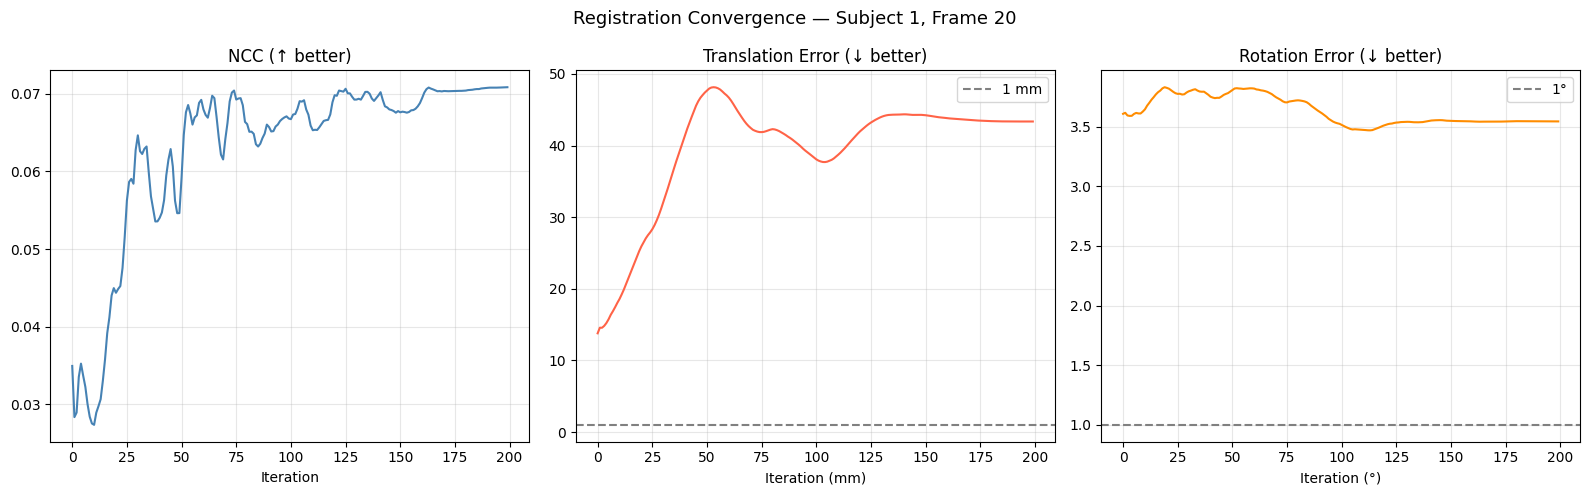

Saved!


In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Registration Convergence — Subject {SUBJECT_ID}, Frame {FRAME_IDX}', fontsize=13)

axes[0].plot(history['ncc'], color='steelblue')
axes[0].set_title('NCC (↑ better)'); axes[0].set_xlabel('Iteration'); axes[0].grid(alpha=0.3)

axes[1].plot(history['trans_err'], color='tomato')
axes[1].axhline(1.0, color='gray', ls='--', label='1 mm')
axes[1].set_title('Translation Error (↓ better)'); axes[1].set_xlabel('Iteration (mm)')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(history['rot_err'], color='darkorange')
axes[2].axhline(1.0, color='gray', ls='--', label='1°')
axes[2].set_title('Rotation Error (↓ better)'); axes[2].set_xlabel('Iteration (°)')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/registration_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

np.save('../outputs/registration_history.npy', history)
print('Saved!')

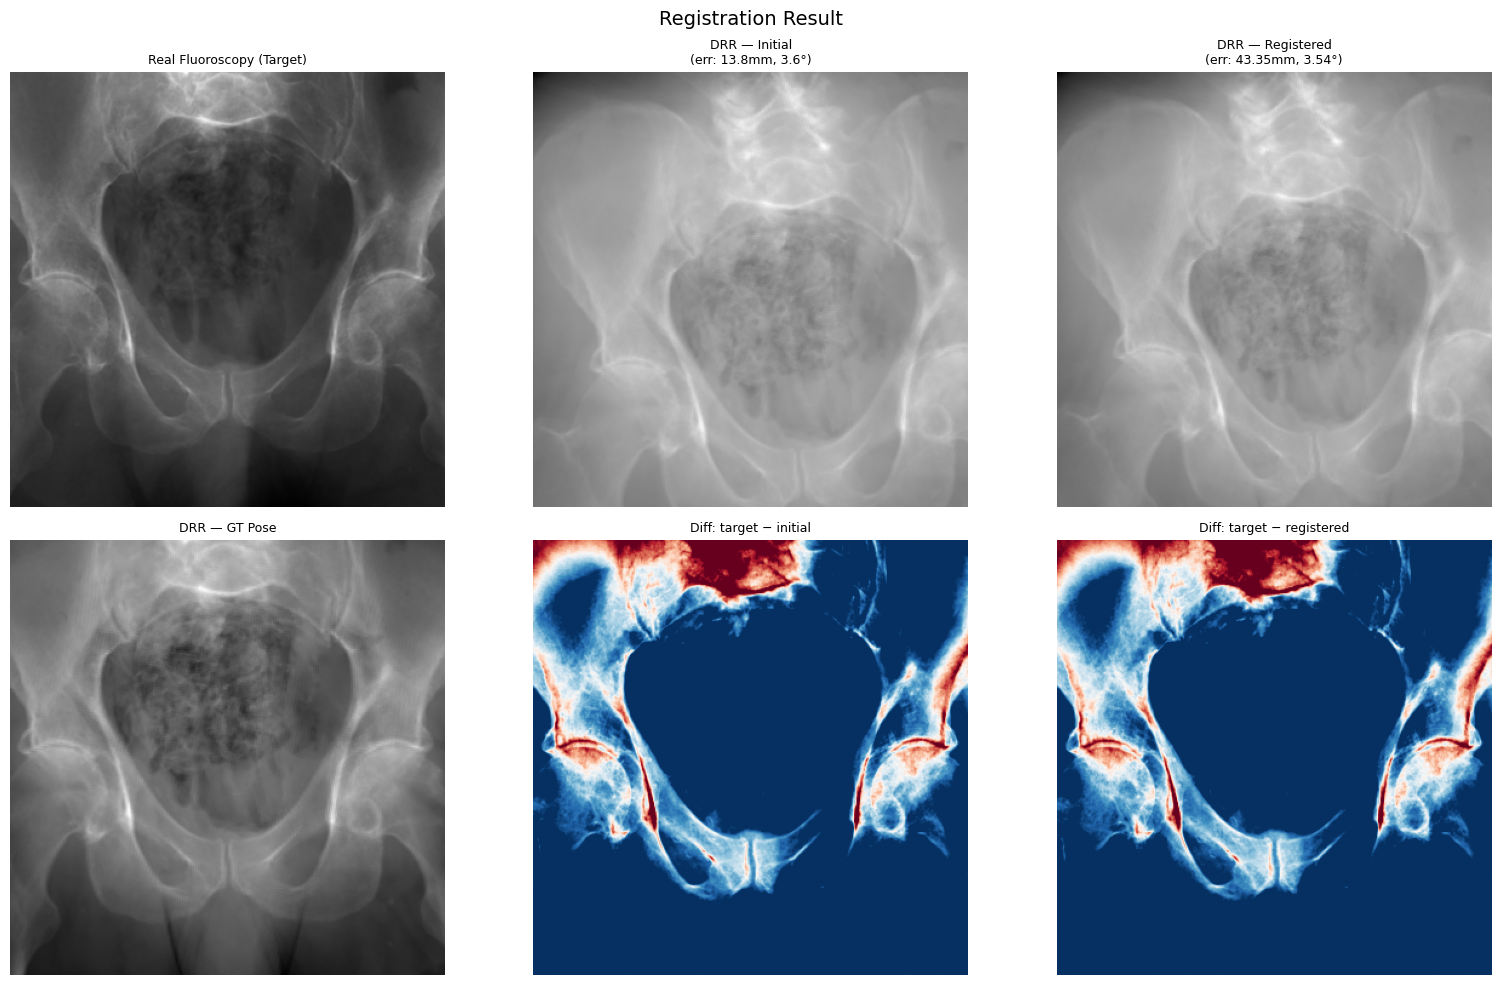

In [29]:
with torch.no_grad():
    drr_final = transform(drr(pose_opt.get_pose()).cpu())

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Registration Result', fontsize=14)

images = [
    (gt_img_t,   'Real Fluoroscopy (Target)'),
    (drr_init,   f'DRR — Initial\n(err: {history["trans_err"][0]:.1f}mm, {history["rot_err"][0]:.1f}°)'),
    (drr_final,  f'DRR — Registered\n(err: {history["trans_err"][-1]:.2f}mm, {history["rot_err"][-1]:.2f}°)'),
    (drr_gt,     'DRR — GT Pose'),
    (gt_img_t - drr_init.clamp(-1,1),  'Diff: target − initial'),
    (gt_img_t - drr_final.clamp(-1,1), 'Diff: target − registered'),
]

for ax, (img, title) in zip(axes.flat, images):
    cmap = 'RdBu_r' if 'Diff' in title else 'gray'
    vmin, vmax = (-1, 1) if 'Diff' in title else (None, None)
    ax.imshow(img.squeeze().numpy(), cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=9); ax.axis('off')

plt.tight_layout()
plt.savefig('../outputs/registration_result.png', dpi=150, bbox_inches='tight')
plt.show()

# Run registration for 3 different perturbation seeds on the same frame
SEEDS       = [1, 10, 100]
N_ITER      = 200
ROT_PERTURB = 5.0
TRANS_PERTURB = 10.0

all_histories  = {}
all_poses      = {}
all_rendered   = {}
all_pose_mats  = {}

for seed in SEEDS:
    print(f'\n── Seed {seed} ──────────────────────────')
    torch.manual_seed(seed)

    init_pose = perturb_pose(gt_pose, rot_deg=ROT_PERTURB, trans_mm=TRANS_PERTURB)
    init_t    = init_pose.matrix[0, :3, 3].numpy()
    gt_t      = gt_pose.matrix[0, :3, 3].numpy()
    print(f'  Initial trans error: {np.linalg.norm(gt_t - init_t):.2f} mm')

    # Storage for animation frames
    rendered_frames = []
    pose_matrices   = []

    target   = transform(gt_img).to(device)
    ncc_fn   = NormalizedCrossCorrelation2d(patch_size=9)
    pose_opt = PoseOptimizer(init_pose.to(device)).to(device)

    optimizer = torch.optim.Adam([
        {'params': pose_opt.log_rot, 'lr': 1e-3},
        {'params': pose_opt.trans,   'lr': 1.0},
    ])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=N_ITER, eta_min=1e-5)

    gt_mat  = gt_pose.matrix[0].numpy()
    history = {'ncc': [], 'trans_err': [], 'rot_err': []}

    for i in tqdm(range(N_ITER), desc=f'Seed {seed}'):
        optimizer.zero_grad()
        pose       = pose_opt.get_pose()
        rendered_t = transform(drr(pose))
        loss       = -ncc_fn(rendered_t.to(device), target)
        loss.backward()
        optimizer.step()
        scheduler.step()

        with torch.no_grad():
            cur_mat   = pose_opt.get_pose().matrix[0].detach().cpu().numpy()
            trans_err = np.linalg.norm(cur_mat[:3,3] - gt_mat[:3,3])
            rot_mat   = cur_mat[:3,:3] @ gt_mat[:3,:3].T
            rot_err   = np.degrees(np.arccos(np.clip((np.trace(rot_mat)-1)/2, -1, 1)))
            history['ncc'].append(-loss.item())
            history['trans_err'].append(float(trans_err))
            history['rot_err'].append(float(rot_err))

            # Save every 2nd frame for animation
            if i % 2 == 0:
                rendered_frames.append(
                    transform(drr(pose_opt.get_pose()).cpu()).squeeze().numpy()
                )
                pose_matrices.append(
                    pose_opt.get_pose().matrix[0].detach().cpu().numpy()
                )

    all_histories[seed]  = history
    all_poses[seed]      = pose_opt.get_pose()
    all_rendered[seed]   = rendered_frames
    all_pose_mats[seed]  = pose_matrices

    print(f'  Final trans error: {history["trans_err"][-1]:.2f} mm')
    print(f'  Final rot error:   {history["rot_err"][-1]:.2f}°')
    print(f'  Final NCC:         {history["ncc"][-1]:.5f}')

print('\n✅ All 3 seeds complete')

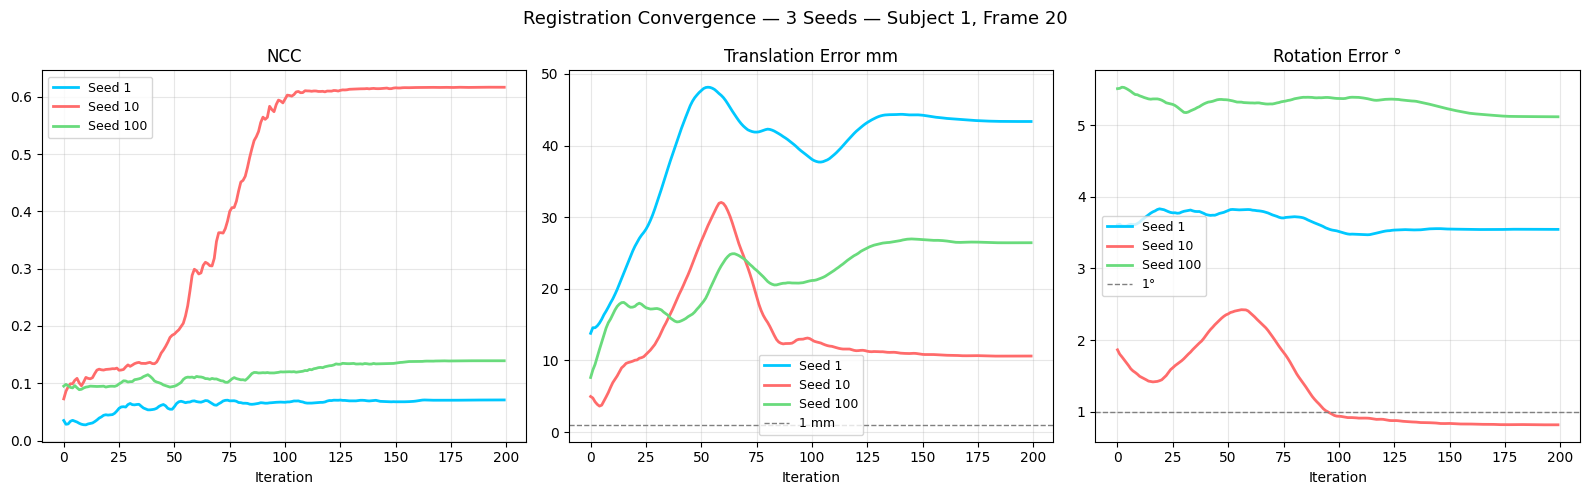

Saved: registration_3seeds.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Registration Convergence — 3 Seeds — Subject {SUBJECT_ID}, Frame {FRAME_IDX}',
             fontsize=13)

colors = {1: '#00c8ff', 10: '#ff6b6b', 100: '#69db7c'}
iters  = range(N_ITER)

for seed in SEEDS:
    h = all_histories[seed]
    lbl = f'Seed {seed}'
    axes[0].plot(h['ncc'],       color=colors[seed], lw=2, label=lbl)
    axes[1].plot(h['trans_err'], color=colors[seed], lw=2, label=lbl)
    axes[2].plot(h['rot_err'],   color=colors[seed], lw=2, label=lbl)

axes[0].set_title('NCC');           axes[0].set_xlabel('Iteration')
axes[1].set_title('Translation Error mm'); axes[1].set_xlabel('Iteration')
axes[2].set_title('Rotation Error °');     axes[2].set_xlabel('Iteration')

axes[1].axhline(1.0, color='gray', ls='--', lw=1, label='1 mm')
axes[2].axhline(1.0, color='gray', ls='--', lw=1, label='1°')

for ax in axes:
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/registration_3seeds.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: registration_3seeds.png')

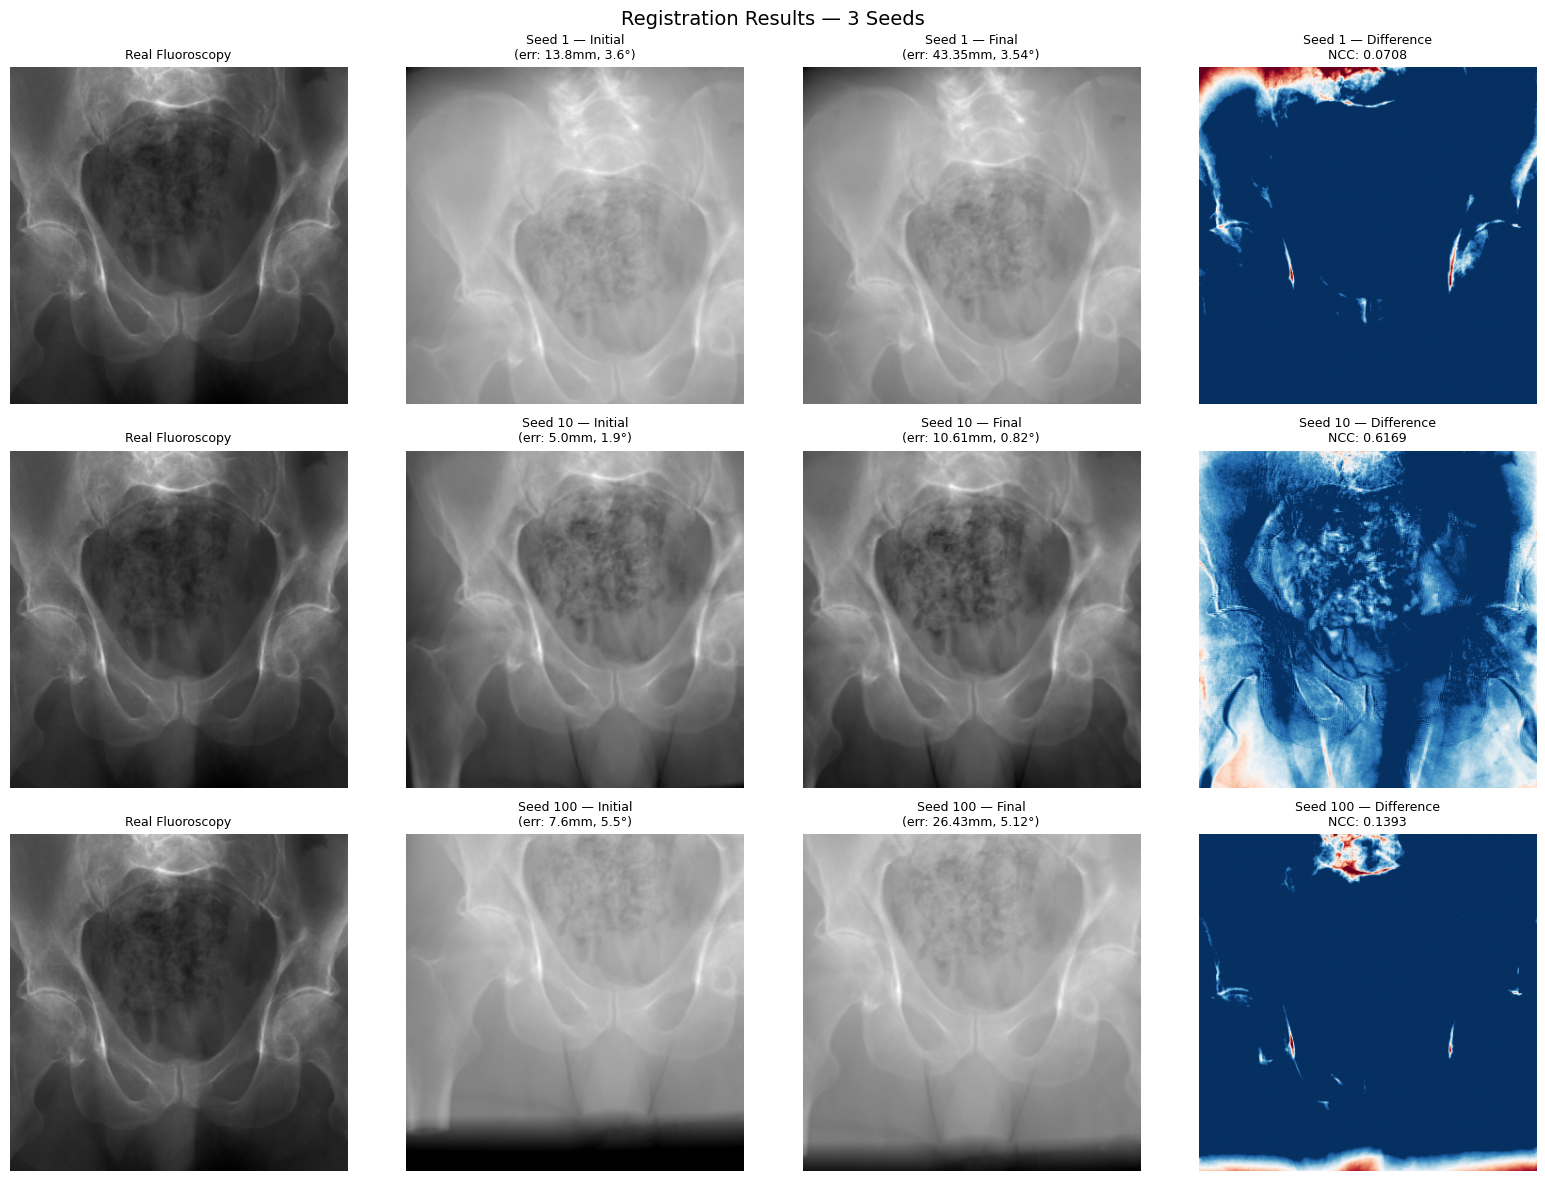

Saved: registration_3seeds_visual.png


In [9]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Registration Results — 3 Seeds', fontsize=14)

gt_np = transform(gt_img).squeeze().numpy()

for row, seed in enumerate(SEEDS):
    h = all_histories[seed]
    with torch.no_grad():
        final_drr = transform(drr(all_poses[seed]).cpu())

    final_np = final_drr.squeeze().numpy()

    axes[row, 0].imshow(gt_np, cmap='gray')
    axes[row, 0].set_title(f'Real Fluoroscopy', fontsize=9)

    axes[row, 1].imshow(all_rendered[seed][0], cmap='gray')
    axes[row, 1].set_title(f'Seed {seed} — Initial\n'
                            f'(err: {h["trans_err"][0]:.1f}mm, {h["rot_err"][0]:.1f}°)',
                            fontsize=9)

    axes[row, 2].imshow(final_np, cmap='gray')
    axes[row, 2].set_title(f'Seed {seed} — Final\n'
                            f'(err: {h["trans_err"][-1]:.2f}mm, {h["rot_err"][-1]:.2f}°)',
                            fontsize=9)

    diff = gt_np - final_np
    axes[row, 3].imshow(diff, cmap='RdBu_r', vmin=-1, vmax=1)
    axes[row, 3].set_title(f'Seed {seed} — Difference\nNCC: {h["ncc"][-1]:.4f}', fontsize=9)

    for ax in axes[row]: ax.axis('off')

plt.tight_layout()
plt.savefig('../outputs/registration_3seeds_visual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: registration_3seeds_visual.png')

In [10]:
# Pick the best seed (lowest final translation error)
best_seed = min(SEEDS, key=lambda s: all_histories[s]['trans_err'][-1])
print(f'Best seed: {best_seed}')
print(f'  Final trans error: {all_histories[best_seed]["trans_err"][-1]:.2f} mm')
print(f'  Final rot error:   {all_histories[best_seed]["rot_err"][-1]:.2f}°')

# Save for animation notebook
np.save('../outputs/rendered_frames.npy',      np.stack(all_rendered[best_seed]))
np.save('../outputs/pose_matrices.npy',        np.stack(all_pose_mats[best_seed]))
np.save('../outputs/gt_image.npy',             gt_np)
np.save('../outputs/registration_history.npy', all_histories[best_seed])

print(f'\n✅ Saved {len(all_rendered[best_seed])} animation frames from seed {best_seed}')
print('Ready to run animation notebook!')

Best seed: 10
  Final trans error: 10.61 mm
  Final rot error:   0.82°

✅ Saved 100 animation frames from seed 10
Ready to run animation notebook!
